Import Module

In [44]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from xgboost.callback import EarlyStopping
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score, f1_score
import joblib

Data Preprocessing

In [14]:
df = pd.read_csv('air_quality_dataset.csv')

In [15]:
df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [16]:
df.drop(['PM2.5', 'PM10', 'NO2', 'SO2', 'Proximity_to_Industrial_Areas', 'Population_Density'], axis=1, inplace=True)
df.head()

,Temperature,Humidity,CO,Air Quality
0,29.8,59.1,1.72,Moderate
1,28.3,75.6,1.64,Moderate
2,23.1,74.7,1.63,Moderate
3,27.1,39.1,1.15,Good
4,26.5,70.7,1.01,Good


In [17]:
# Temperature (Celcius) - Float
# Humidity (%) - Float
# CO (ppm) - Float
# Air Quality - Category

df.dtypes

Temperature    float64
Humidity       float64
CO             float64
Air Quality     object
dtype: object

In [18]:
# Check all the unique values from 'Air Quality' column
df['Air Quality'].unique()

array(['Moderate', 'Good', 'Hazardous', 'Poor'], dtype=object)

In [19]:
# Convert'Air Quality' to Categoruical

quality_mapping = {
    'Good': 0,
    'Moderate': 1,
    'Poor': 2,
    'Hazardous': 3
}

df['Air Quality'] = df['Air Quality'].map(quality_mapping)
df.head()


,Temperature,Humidity,CO,Air Quality
0,29.8,59.1,1.72,1
1,28.3,75.6,1.64,1
2,23.1,74.7,1.63,1
3,27.1,39.1,1.15,0
4,26.5,70.7,1.01,0


Data Splitting

In [20]:
# X is Independent Variables

X = df.drop(['Air Quality'], axis=1)
X.head()

,Temperature,Humidity,CO
0,29.8,59.1,1.72
1,28.3,75.6,1.64
2,23.1,74.7,1.63
3,27.1,39.1,1.15
4,26.5,70.7,1.01


In [21]:
# y is Dependent Variable

y = df[['Air Quality']].copy()
y.head()

,Air Quality
0,1
1,1
2,1
3,0
4,0


Model Training

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [23]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Now, X_resampled and y_resampled are your balanced training datasets
print("Original training data shape:", X_train.shape)
print("Resampled training data shape:", X_resampled.shape)
print("Distribution of resampled labels:\n", y_resampled.value_counts())

Original training data shape: (3750, 3)
Resampled training data shape: (6000, 3)
Distribution of resampled labels:
 Air Quality
0              1500
1              1500
2              1500
3              1500
Name: count, dtype: int64


In [26]:
clf_xgb = xgb.XGBClassifier(
    objective='multi:softprob', 
    eval_metric='aucpr',
    missing=np.nan, 
    seed=42,
    num_class= 4,
    early_stopping_rounds = 10
)

clf_xgb.fit(
    X_resampled, 
    y_resampled,
    eval_set=[(X_test, y_test)],
    verbose=True
)


[0]	validation_0-aucpr:0.87735
[1]	validation_0-aucpr:0.88640
[2]	validation_0-aucpr:0.88460
[3]	validation_0-aucpr:0.88873
[4]	validation_0-aucpr:0.89121
[5]	validation_0-aucpr:0.89220
[6]	validation_0-aucpr:0.89329
[7]	validation_0-aucpr:0.89486
[8]	validation_0-aucpr:0.89702
[9]	validation_0-aucpr:0.89667
[10]	validation_0-aucpr:0.89698
[11]	validation_0-aucpr:0.89721
[12]	validation_0-aucpr:0.89778
[13]	validation_0-aucpr:0.89914
[14]	validation_0-aucpr:0.89973
[15]	validation_0-aucpr:0.90017
[16]	validation_0-aucpr:0.90011
[17]	validation_0-aucpr:0.89939
[18]	validation_0-aucpr:0.89924
[19]	validation_0-aucpr:0.89955
[20]	validation_0-aucpr:0.90015
[21]	validation_0-aucpr:0.89962
[22]	validation_0-aucpr:0.90086
[23]	validation_0-aucpr:0.90131
[24]	validation_0-aucpr:0.90091
[25]	validation_0-aucpr:0.90066
[26]	validation_0-aucpr:0.90080
[27]	validation_0-aucpr:0.89955
[28]	validation_0-aucpr:0.89781
[29]	validation_0-aucpr:0.89885
[30]	validation_0-aucpr:0.89818
[31]	validation_0-

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=4, ...)

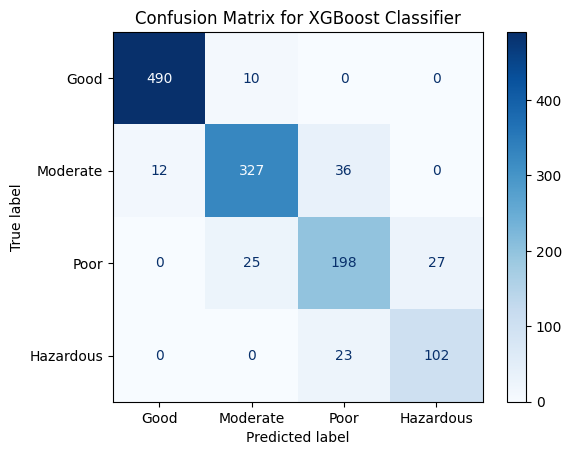

In [27]:
y_pred = clf_xgb.predict(X_test)
y_true = y_test
labels = ['Good', 'Moderate', 'Poor', 'Hazardous']

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")
plt.show()

In [42]:
y_pred = clf_xgb.predict(X_test)
y_true = y_test

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.2f}")

f1_macro = f1_score(y_true, y_pred, average='macro')
print(f"Macro-Averaged F1 Score: {f1_macro:.2f}")

Accuracy: 0.89
Macro-Averaged F1 Score: 0.86


In [45]:
joblib.dump(clf_xgb, 'xgb_model_air_quality.pkl')
print("Model exported successfully as 'air_quality_model.pkl'.")

Model exported successfully as 'air_quality_model.pkl'.


Optimization

In [ ]:
#Round 1
# Correct parameter names and values for hyperparameter tuning
# param_grid = {
#     'max_depth': [3, 4, 5],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'gamma': [0, 0.25, 1],
#     'reg_lambda': [0, 1, 10]
# }
#
# Result
# gamma: 0.25
# learning_rate: 0.1
# max_depth: 5

#Round 2

# param_grid = {
#     'max_depth': [5, 10, 15],
#     'learning_rate': [0.1, 1, 10],
#     'gamma': [0.25],
#     'reg_lambda': [1]
# }

# Result
# gamma: 0.25
# Learning rate = 0.1
# Max Depth = 15


# Round 3
# param_grid = {
#     'max_depth': [15, 30, 45],
#     'learning_rate': [0.1],
#     'gamma': [0.25],
#     'reg_lambda': [1]
# }

# Result
# gamma: 0.25
# Learning rate = 0.1
# Max Depth = 15

# The XGBoost model with fixed parameters
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='aucpr',
    missing=np.nan,
    seed=42,
    num_class=4
)

# Setup GridSearchCV with the correct parameters
optimal_params = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1, #
    cv=3
)

# Fit the GridSearchCV model with the correct parameters for early stopping
fit_params = {
    'eval_set': [(X_test, y_test)],
    'verbose': False
}

optimal_params.fit(X_resampled, y_resampled, **fit_params)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='aucpr', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=4, ...),
             n_jobs=-1,
             param_grid={'gamma': [0.25], 'learning_rate': [0.1],
                         'max_depth': [15, 30, 45], 'reg_lambda': [1]},
             scoring='f1_macro', verbose=1)

Final XGB Classifier

In [ ]:
clf_xgb_final = xgb.XGBClassifier(
    objective='multi:softprob', 
    eval_metric='aucpr',
    missing=np.nan, 
    seed=42,
    num_class= 4,
    early_stopping_rounds = 10,
    gamma = 0.25,
    learning_rate = 0.1,
    max_depth = 15,
    subsample = 0.9,
    colsample_bytree = 0.5
)

clf_xgb_final.fit(
    X_resampled, 
    y_resampled,
    eval_set=[(X_test, y_test)],
    verbose=True
)


[0]	validation_0-aucpr:0.77691
[1]	validation_0-aucpr:0.81291
[2]	validation_0-aucpr:0.81379
[3]	validation_0-aucpr:0.82921
[4]	validation_0-aucpr:0.83080
[5]	validation_0-aucpr:0.83678
[6]	validation_0-aucpr:0.84075
[7]	validation_0-aucpr:0.84999
[8]	validation_0-aucpr:0.85246
[9]	validation_0-aucpr:0.84954
[10]	validation_0-aucpr:0.84784
[11]	validation_0-aucpr:0.84589
[12]	validation_0-aucpr:0.84286
[13]	validation_0-aucpr:0.84738
[14]	validation_0-aucpr:0.84839
[15]	validation_0-aucpr:0.84884
[16]	validation_0-aucpr:0.84857
[17]	validation_0-aucpr:0.84747


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=0.25, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=15,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=4, ...)

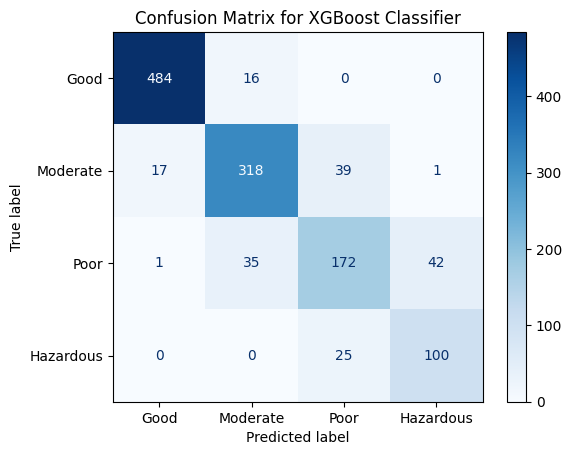

In [39]:
y_pred_final = clf_xgb_final.predict(X_test)
y_true_final = y_test
labels = ['Good', 'Moderate', 'Poor', 'Hazardous']

cm = confusion_matrix(y_true_final, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")
plt.show()

In [43]:
y_pred_final = clf_xgb_final.predict(X_test)
y_true_final = y_test

accuracy = accuracy_score(y_true_final, y_pred_final)
print(f"Accuracy: {accuracy:.2f}")

f1_macro = f1_score(y_true_final, y_pred_final, average='macro')
print(f"Macro-Averaged F1 Score: {f1_macro:.2f}")

Accuracy: 0.86
Macro-Averaged F1 Score: 0.82
